# 🐱‍🔮 Sudoku Master — Entrenar CNN OCR con fuentes impresas
En vez de MNIST (dígitos manuscritos), genero dígitos con **fuentes tipográficas** (Arial, DejaVu, Liberation, etc.) que se parecen a los sudokus impresos reales.

Con augmentation (rotaciones, desenfoque, ruido) para simular fotos de móvil.
Guarda el modelo en `../modelos/modelo_ocr.keras`. Ejecutar UNA VEZ.

## PASO 0 · Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob, random
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import cv2
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

RUTA_MODELO_OCR = Path('../modelos/modelo_ocr.keras')
print('✓ Imports OK')

✓ Imports OK


## PASO 1 · Localizar fuentes del sistema
Busca fuentes TrueType instaladas. En Windows están en C:/Windows/Fonts.

In [2]:
# Rutas típicas de fuentes según el sistema operativo
posibles = [
    'C:/Windows/Fonts/*.ttf',                 # Windows
    '/usr/share/fonts/**/*.ttf',              # Linux
    '/System/Library/Fonts/**/*.ttf',         # macOS
    '/Library/Fonts/*.ttf',                   # macOS
]

todas = []
for patron in posibles:
    todas += glob.glob(patron, recursive=True)

# Fuentes que se parecen a sudokus impresos (sans, serif, mono)
preferidas = ['arial', 'times', 'cour', 'calibri', 'verdana', 'tahoma',
              'georgia', 'segoeui', 'dejavu', 'liberation', 'free', 'poppins',
              'roboto', 'opensans', 'lato']

fuentes = []
for ruta in todas:
    nombre = Path(ruta).stem.lower()
    if any(p in nombre for p in preferidas) and 'italic' not in nombre and 'oblique' not in nombre:
        fuentes.append(ruta)

# Si no encuentra ninguna preferida, usar todas las disponibles
if not fuentes:
    fuentes = todas[:20]

fuentes = sorted(set(fuentes))
print(f'✓ {len(fuentes)} fuentes encontradas:')
for f in fuentes[:20]:
    print(f'  {Path(f).name}')

✓ 100 fuentes encontradas:
  ARIALN.TTF
  ARIALNB.TTF
  ARIALNBI.TTF
  ARIALNI.TTF
  ArialNova-Bold.ttf
  ArialNova-Light.ttf
  ArialNova.ttf
  ArialNovaCond-Bold.ttf
  ArialNovaCond-Light.ttf
  ArialNovaCond.ttf
  DejaVuMathTeXGyre.ttf
  DejaVuSans-Bold.ttf
  DejaVuSans-ExtraLight.ttf
  DejaVuSans.ttf
  DejaVuSansCondensed-Bold.ttf
  DejaVuSansCondensed.ttf
  DejaVuSansMono-Bold.ttf
  DejaVuSansMono.ttf
  DejaVuSerif-Bold.ttf
  DejaVuSerif.ttf


## PASO 2 · Generar el dataset de dígitos
Para cada dígito 1-9, lo dibujo con cada fuente en varios tamaños y posiciones,
y aplico augmentation (rotación, desenfoque, ruido) para simular fotos reales.
La clase 0 (vacía) son celdas de fondo con ruido.

In [3]:
def generar_digito(digito, ruta_fuente, size=28):
    """Dibuja un dígito con una fuente. Dígito negro sobre fondo blanco."""
    img  = Image.new('L', (size, size), color=255)
    draw = ImageDraw.Draw(img)
    fsize = random.randint(16, 24)
    try:
        font = ImageFont.truetype(ruta_fuente, fsize)
    except Exception:
        return None
    s = str(digito)
    bbox = draw.textbbox((0, 0), s, font=font)
    w, h = bbox[2]-bbox[0], bbox[3]-bbox[1]
    # Centrar con pequeño desplazamiento aleatorio
    dx = random.randint(-2, 2)
    dy = random.randint(-2, 2)
    x = (size - w)//2 - bbox[0] + dx
    y = (size - h)//2 - bbox[1] + dy
    draw.text((x, y), s, fill=0, font=font)
    return np.array(img)

def augmentar(img):
    """Aplica rotación leve, desenfoque y ruido para simular foto real."""
    # Rotación leve
    ang = random.uniform(-8, 8)
    M = cv2.getRotationMatrix2D((14, 14), ang, 1.0)
    img = cv2.warpAffine(img, M, (28, 28), borderValue=255)
    # Desenfoque aleatorio
    if random.random() < 0.5:
        k = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (k, k), 0)
    # Ruido gaussiano
    if random.random() < 0.5:
        ruido = np.random.normal(0, random.uniform(5, 20), (28, 28))
        img = np.clip(img.astype(np.float32) + ruido, 0, 255).astype(np.uint8)
    # Variación de brillo (simula sombras)
    if random.random() < 0.3:
        img = np.clip(img.astype(np.float32) * random.uniform(0.7, 1.0), 0, 255).astype(np.uint8)
    return img

# Cuántas variaciones por (dígito, fuente)
VARIACIONES = 40

X, y = [], []

# Dígitos 1-9
for digito in range(1, 10):
    for fuente in fuentes:
        base = generar_digito(digito, fuente)
        if base is None:
            continue
        for _ in range(VARIACIONES):
            X.append(augmentar(base))
            y.append(digito)

# Clase 0: celdas vacías (fondo blanco con ruido y a veces restos de línea)
N_VACIAS = len(X) // 9
for _ in range(N_VACIAS):
    img = np.full((28, 28), random.randint(220, 255), dtype=np.uint8)
    ruido = np.random.normal(0, random.uniform(3, 15), (28, 28))
    img = np.clip(img.astype(np.float32) + ruido, 0, 255).astype(np.uint8)
    # A veces una línea de cuadrícula en el borde
    if random.random() < 0.3:
        lado = random.choice(['top','bottom','left','right'])
        gris = random.randint(80, 160)
        if lado=='top':    img[:2,:] = gris
        if lado=='bottom': img[-2:,:] = gris
        if lado=='left':   img[:,:2] = gris
        if lado=='right':  img[:,-2:] = gris
    X.append(img)
    y.append(0)

X = np.array(X, dtype='float32') / 255.0
y = np.array(y)
idx = np.random.permutation(len(X))
X, y = X[idx][..., np.newaxis], y[idx]

print(f'✓ Dataset generado: {len(X)} imágenes, {len(np.unique(y))} clases')
for c in range(10):
    label = 'vacía' if c == 0 else str(c)
    print(f'  Clase {c} ({label:5s}): {np.sum(y == c)}')

✓ Dataset generado: 40000 imágenes, 10 clases
  Clase 0 (vacía): 4000
  Clase 1 (1    ): 4000
  Clase 2 (2    ): 4000
  Clase 3 (3    ): 4000
  Clase 4 (4    ): 4000
  Clase 5 (5    ): 4000
  Clase 6 (6    ): 4000
  Clase 7 (7    ): 4000
  Clase 8 (8    ): 4000
  Clase 9 (9    ): 4000


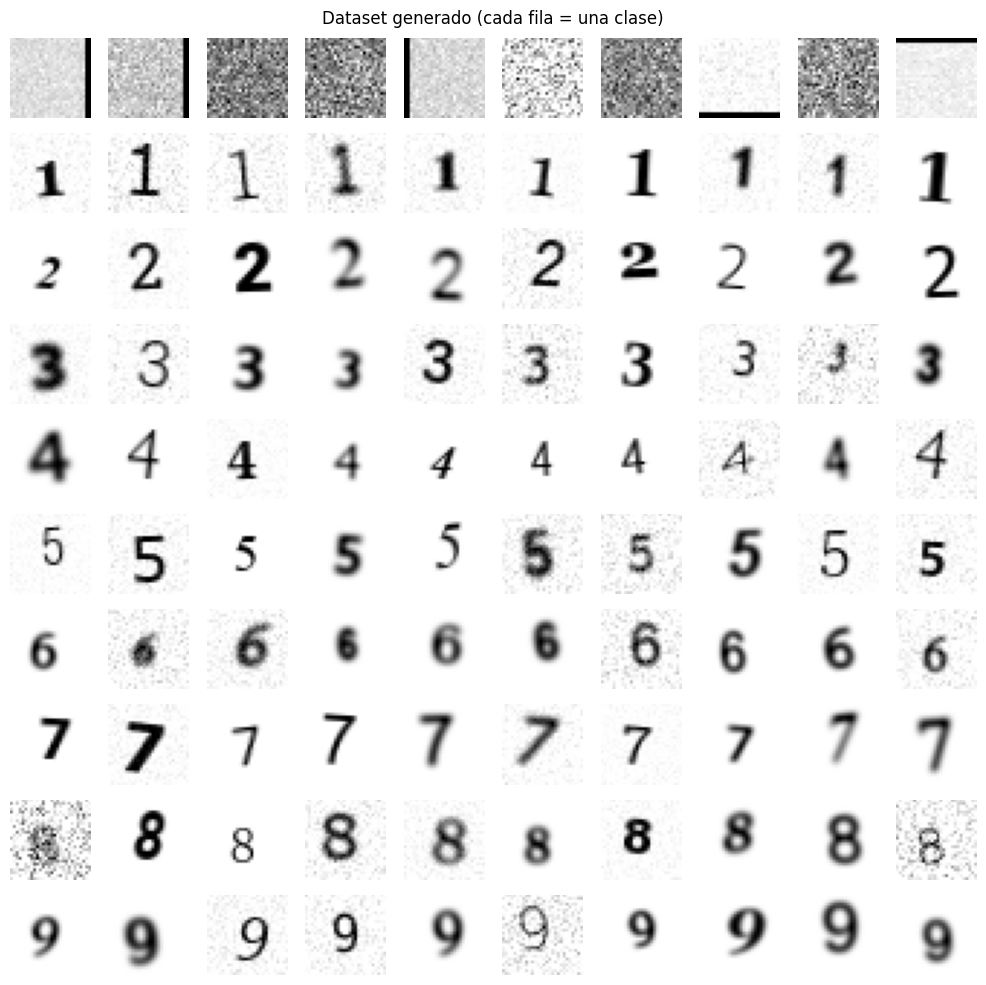

In [4]:
# Visualizar muestra del dataset generado
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for c in range(10):
    ejemplos = np.where(y == c)[0][:10]
    for k, e in enumerate(ejemplos):
        axes[c][k].imshow(X[e, :, :, 0], cmap='gray')
        axes[c][k].axis('off')
    axes[c][0].set_ylabel(str(c), rotation=0, labelpad=15, fontsize=12)
plt.suptitle('Dataset generado (cada fila = una clase)', fontsize=12)
plt.tight_layout()
plt.show()

## PASO 3 · Definir y entrenar la CNN

In [5]:
modelo_ocr = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='modelo_ocr_fuentes')

modelo_ocr.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)
]

historia = modelo_ocr.fit(
    X, y, epochs=20, batch_size=128, validation_split=0.1, callbacks=callbacks
)

acc = max(historia.history['val_accuracy'])
print(f'\n✓ Mejor val_accuracy: {acc:.4f} ({acc*100:.2f}%)')

Epoch 1/20


c:\Users\rober\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 79ms/step - accuracy: 0.7014 - loss: 0.8723 - val_accuracy: 0.1160 - val_loss: 5.6981 - learning_rate: 0.0010
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.9594 - loss: 0.1188 - val_accuracy: 0.9790 - val_loss: 0.0603 - learning_rate: 0.0010
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.9799 - loss: 0.0611 - val_accuracy: 0.9992 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step - accuracy: 0.9868 - loss: 0.0411 - val_accuracy: 0.9983 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 5/20
281/282 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9893 - loss: 0.0350
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
282/282 ━━━━━━━━━━━━━━━━━━━━ 25s 87ms/step - accuracy: 0.9912 - loss: 0.0281 - val_accuracy: 0.9980 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 86ms/step - accuracy: 0.9946 - loss: 0.0169 -

## PASO 4 · Matriz de confusión

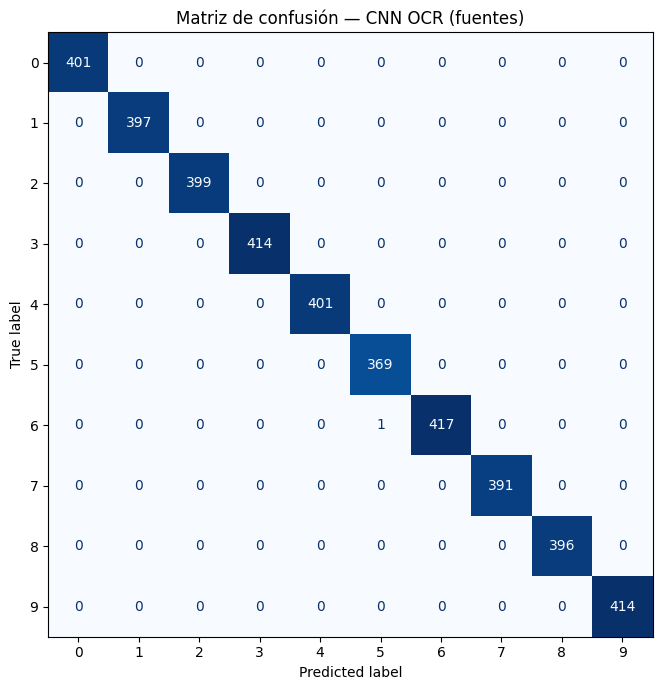

In [6]:
split  = int(len(X) * 0.9)
y_pred = np.argmax(modelo_ocr.predict(X[split:], verbose=0), axis=1)
cm = confusion_matrix(y[split:], y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de confusión — CNN OCR (fuentes)')
plt.tight_layout()
plt.show()

## PASO 5 · Guardar modelo

In [7]:
RUTA_MODELO_OCR.parent.mkdir(parents=True, exist_ok=True)
modelo_ocr.save(str(RUTA_MODELO_OCR))
print(f'✓ Modelo guardado en {RUTA_MODELO_OCR.resolve()}')
print('  Ya puedes ejecutar el notebook principal (sudoku_local_v2.ipynb)')

✓ Modelo guardado en C:\Users\rober\OneDrive\Documentos\Bootcamp The Bridge\sudoku_master\modelos\modelo_ocr.keras
  Ya puedes ejecutar el notebook principal (sudoku_local_v2.ipynb)
